# Research Retrospective: From SSL Exploration to the Current Supervised Baseline

**Objective**

This notebook turns the project into a compact research report. It reconstructs the full arc:
the original SSL question, the supervised baseline correction, the supervised-only sweep phase,
the final Adam vs AdamW decision, and the current promoted baseline.

**Success criteria**

- Explain how the project evolved from SSL exploration into a supervised-first result
- Reuse the stored experiment outputs instead of retraining
- Prefer live result directories when they are present, but fall back to compact summary artifacts
- End with a clear statement of the current best model and the next clinically relevant steps


In [1]:
from __future__ import annotations

import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import Markdown, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.9)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)


def find_project_root(start: Path | None = None) -> Path:
    candidate = (start or Path.cwd()).resolve()
    for path in [candidate, *candidate.parents]:
        if (path / "README.md").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError("Could not locate project root from notebook context.")


PROJECT_ROOT = find_project_root()
NOTEBOOK_PATH = PROJECT_ROOT / "notebooks" / "05_research_retrospective.ipynb"

LIVE_RESULTS = {
    "final_head_to_head": PROJECT_ROOT / "results_supervised_final_head_to_head",
    "ls_optimizer_recovery": PROJECT_ROOT / "results_supervised_ls_optimizer_recovery",
    "supervised_candidates": PROJECT_ROOT / "results_supervised_candidates",
    "supervised_sweep": PROJECT_ROOT / "results_supervised_sweep",
}
REPORT_FILES = {
    "ssl_closure_csv": PROJECT_ROOT / "reports" / "ssl_closure_summary.csv",
    "final_results_md": PROJECT_ROOT / "reports" / "final_results.md",
    "current_progress_md": PROJECT_ROOT / "reports" / "current_progress_brief.md",
}

status_rows = []
for name, path in LIVE_RESULTS.items():
    status_rows.append({"kind": "live_results", "name": name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()})
for name, path in REPORT_FILES.items():
    status_rows.append({"kind": "report", "name": name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()})
status_df = pd.DataFrame(status_rows)
display(status_df)


,kind,name,path,exists
0,live_results,final_head_to_head,results_supervised_final_head_to_head,True
1,live_results,ls_optimizer_recovery,results_supervised_ls_optimizer_recovery,True
2,live_results,supervised_candidates,results_supervised_candidates,True
3,live_results,supervised_sweep,results_supervised_sweep,True
4,report,ssl_closure_csv,reports/ssl_closure_summary.csv,True
5,report,final_results_md,reports/final_results.md,True
6,report,current_progress_md,reports/current_progress_brief.md,True


## Research Arc Overview

The project moved through four concrete phases. It started as a low-label SSL question, then a corrected
supervised baseline changed the interpretation of the earlier experiments, which led to a supervised sweep
phase and finally a promoted baseline chosen using clinical-style evaluation rather than raw AUC alone.


In [2]:
timeline = pd.DataFrame(
    [
        {
            "phase": "Phase 1",
            "focus": "Supervised vs SSL starting point",
            "decision": "Test vanilla FixMatch and Mean Teacher against a supervised baseline",
        },
        {
            "phase": "Phase 2",
            "focus": "Baseline correction",
            "decision": "Freeze behavior bug depressed supervised results, so the comparison had to be reset",
        },
        {
            "phase": "Phase 3",
            "focus": "Supervised sweeps",
            "decision": "512px EfficientNet-B0 stayed strongest; label smoothing emerged as the best regularization branch",
        },
        {
            "phase": "Phase 4",
            "focus": "Final optimizer head-to-head",
            "decision": "AdamW beat Adam on the promoted label-smoothing family and became the current baseline",
        },
    ]
)
timeline


,phase,focus,decision
0,Phase 1,Supervised vs SSL starting point,Test vanilla FixMatch and Mean Teacher against a supervised baseline
1,Phase 2,Baseline correction,"Freeze behavior bug depressed supervised results, so the comparison had to be reset"
2,Phase 3,Supervised sweeps,512px EfficientNet-B0 stayed strongest; label smoothing emerged as the best regularization branch
3,Phase 4,Final optimizer head-to-head,AdamW beat Adam on the promoted label-smoothing family and became the current baseline


In [3]:
FALLBACK_SWEEP = pd.DataFrame(
    [
        {"config_name": "default_nofreeze_res512", "mean_val_auc": 0.8575, "mean_test_auc": 0.7518, "family": "baseline"},
        {"config_name": "default_nofreeze_res768", "mean_val_auc": 0.7463, "mean_test_auc": 0.6798, "family": "resolution"},
        {"config_name": "default_nofreeze_res1024", "mean_val_auc": 0.6887, "mean_test_auc": 0.6070, "family": "resolution"},
        {"config_name": "default_nofreeze_b2", "mean_val_auc": 0.8134, "mean_test_auc": 0.7183, "family": "backbone"},
        {"config_name": "default_nofreeze_b3", "mean_val_auc": 0.7847, "mean_test_auc": 0.6577, "family": "backbone"},
        {"config_name": "default_nofreeze_aug_safe", "mean_val_auc": 0.8390, "mean_test_auc": 0.7555, "family": "regularization"},
        {"config_name": "default_nofreeze_ls", "mean_val_auc": 0.8797, "mean_test_auc": 0.7462, "family": "regularization"},
        {"config_name": "default_nofreeze_aug_safe_ls", "mean_val_auc": 0.8503, "mean_test_auc": 0.7284, "family": "regularization"},
    ]
)

FALLBACK_CANDIDATES = pd.DataFrame(
    [
        {"config_name": "default_nofreeze_res512", "mean_val_auc": 0.8575, "mean_test_auc": 0.7518, "mean_sensitivity": 0.7156, "mean_specificity": 0.6468},
        {"config_name": "default_nofreeze_aug_safe", "mean_val_auc": 0.8390, "mean_test_auc": 0.7555, "mean_sensitivity": 0.6480, "mean_specificity": 0.7095},
        {"config_name": "default_nofreeze_ls", "mean_val_auc": 0.8797, "mean_test_auc": 0.7462, "mean_sensitivity": 0.6550, "mean_specificity": 0.6850},
        {"config_name": "default_nofreeze_aug_safe_ls", "mean_val_auc": 0.8503, "mean_test_auc": 0.7284, "mean_sensitivity": 0.6434, "mean_specificity": 0.6835},
    ]
)

FALLBACK_FINAL_FRESH = pd.DataFrame(
    [
        {"config_name": "default_nofreeze_ls_adam", "mean_val_auc": 0.8040, "mean_test_auc": 0.7189, "mean_test_pr_auc": 0.6168, "mean_test_brier_score": 0.2169, "mean_test_ece": 0.1014, "mean_test_sensitivity": 0.6014, "mean_test_specificity": 0.7064, "mean_spec_at_sens_090": 0.4021, "mean_exam_auc": 0.7227},
        {"config_name": "default_nofreeze_ls_adamw", "mean_val_auc": 0.8568, "mean_test_auc": 0.7602, "mean_test_pr_auc": 0.6889, "mean_test_brier_score": 0.2161, "mean_test_ece": 0.1572, "mean_test_sensitivity": 0.7506, "mean_test_specificity": 0.6208, "mean_spec_at_sens_090": 0.5979, "mean_exam_auc": 0.7708},
    ]
)

FALLBACK_FINAL_COMBINED = pd.DataFrame(
    [
        {"config_name": "default_nofreeze_ls_adam", "runs": 6, "mean_val_auc": 0.8418, "mean_test_auc": 0.7326, "mean_test_pr_auc": 0.6437, "mean_test_brier_score": 0.2146, "mean_test_ece": 0.1084, "mean_test_sensitivity": 0.6282, "mean_test_specificity": 0.6957, "mean_spec_at_sens_090": 0.4709, "mean_exam_auc": 0.7424},
        {"config_name": "default_nofreeze_ls_adamw", "runs": 6, "mean_val_auc": 0.8633, "mean_test_auc": 0.7589, "mean_test_pr_auc": 0.6748, "mean_test_brier_score": 0.2188, "mean_test_ece": 0.1513, "mean_test_sensitivity": 0.7110, "mean_test_specificity": 0.6651, "mean_spec_at_sens_090": 0.5833, "mean_exam_auc": 0.7668},
    ]
)


def _relative(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def note(message: str) -> None:
    display(Markdown(f"> {message}"))


def load_ssl_closure() -> pd.DataFrame:
    path = REPORT_FILES["ssl_closure_csv"]
    if path.exists():
        return pd.read_csv(path)
    raise FileNotFoundError("reports/ssl_closure_summary.csv is required for the retrospective notebook.")


def load_supervised_sweep_summary() -> pd.DataFrame:
    path = LIVE_RESULTS["supervised_sweep"] / "supervised_summary_grouped.csv"
    if path.exists():
        df = pd.read_csv(path)
        if "family" not in df.columns:
            def classify_family(config_name: str) -> str:
                if "res768" in config_name or "res1024" in config_name:
                    return "resolution"
                if re.search(r"_b[23]$", config_name):
                    return "backbone"
                if any(token in config_name for token in ["aug_safe", "_ls"]):
                    return "regularization"
                return "baseline"

            df["family"] = df["config_name"].map(classify_family)
        return df
    note("Live supervised sweep summary not found - using compact fallback snapshot.")
    return FALLBACK_SWEEP.copy()


def load_candidate_summary() -> pd.DataFrame:
    path = LIVE_RESULTS["supervised_candidates"] / "candidate_comparison.csv"
    if path.exists():
        df = pd.read_csv(path)
        return df.rename(
            columns={
                "config_name": "config_name",
                "mean_sens": "mean_sensitivity",
                "mean_spec": "mean_specificity",
            }
        )
    note("Live candidate comparison not found - using compact fallback snapshot.")
    return FALLBACK_CANDIDATES.copy()


def load_clinical_grouped_csv(path: Path, fallback: pd.DataFrame, label: str) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    note(f"{label} clinical grouped summary not found - using compact fallback values.")
    return fallback.copy()


def collect_clinical_runs(root: Path) -> list[dict]:
    rows = []
    for path in sorted(root.glob("*/clinical_summary.yaml")):
        data = yaml.safe_load(path.read_text())
        fixed = {float(item["target_sensitivity"]): item for item in data.get("fixed_sensitivity", [])}
        exam = next((g for g in data.get("grouped_metrics", []) if g.get("group_name") == "exam_id"), {})
        rows.append(
            {
                "config_name": data["config_name"],
                "seed": int(data["seed"]),
                "val_auc": float(data["val_metrics"]["auc"]),
                "test_auc": float(data["test_metrics"]["auc"]),
                "test_pr_auc": float(data["test_metrics"]["pr_auc"]),
                "test_brier_score": float(data["test_metrics"]["brier_score"]),
                "test_ece": float(data["test_metrics"]["ece"]),
                "test_sensitivity": float(data["test_metrics"]["sensitivity"]),
                "test_specificity": float(data["test_metrics"]["specificity"]),
                "spec_at_sens_090": float(fixed.get(0.9, {}).get("test_specificity", 0.0)),
                "spec_at_sens_095": float(fixed.get(0.95, {}).get("test_specificity", 0.0)),
                "exam_auc": float(exam.get("auc", 0.0)),
            }
        )
    return rows


def load_combined_head_to_head() -> pd.DataFrame:
    roots = [
        LIVE_RESULTS["ls_optimizer_recovery"] / "clinical_candidates",
        LIVE_RESULTS["final_head_to_head"] / "clinical_candidates",
    ]
    rows = []
    for root in roots:
        if root.exists():
            rows.extend(collect_clinical_runs(root))
    if not rows:
        note("Live head-to-head clinical summaries not found - using compact fallback values.")
        return FALLBACK_FINAL_COMBINED.copy()
    df = pd.DataFrame(rows)
    grouped = (
        df.groupby("config_name", as_index=False)
        .agg(
            runs=("seed", "count"),
            mean_val_auc=("val_auc", "mean"),
            mean_test_auc=("test_auc", "mean"),
            mean_test_pr_auc=("test_pr_auc", "mean"),
            mean_test_brier_score=("test_brier_score", "mean"),
            mean_test_ece=("test_ece", "mean"),
            mean_test_sensitivity=("test_sensitivity", "mean"),
            mean_test_specificity=("test_specificity", "mean"),
            mean_spec_at_sens_090=("spec_at_sens_090", "mean"),
            mean_spec_at_sens_095=("spec_at_sens_095", "mean"),
            mean_exam_auc=("exam_auc", "mean"),
        )
    )
    return grouped.sort_values("mean_val_auc", ascending=False)


def load_fresh_head_to_head() -> pd.DataFrame:
    path = LIVE_RESULTS["final_head_to_head"] / "clinical_candidates" / "clinical_candidates_grouped.csv"
    return load_clinical_grouped_csv(path, FALLBACK_FINAL_FRESH, "Fresh head-to-head")


## Dataset and Evaluation Context

The project uses CBIS-DDSM as its current public-data base. The important modeling detail is that the
research question evolved, but the evaluation standards became stricter over time: patient-aware splitting,
grouped patient/exam reporting, calibration, and specificity at fixed sensitivity targets all became part
of the decision process.


In [4]:
baseline_config = yaml.safe_load((PROJECT_ROOT / "configs" / "default_nofreeze_ls_adamw.yaml").read_text())

dataset_context = pd.DataFrame(
    [
        {
            "dataset": baseline_config["dataset"]["name"],
            "abnormality_type": baseline_config["dataset"]["abnormality_type"],
            "current_image_size": baseline_config["dataset"]["image_size"],
            "active_backbone": baseline_config["model"]["name"],
            "active_optimizer": baseline_config["training"]["optimizer"],
            "label_smoothing": baseline_config["training"]["label_smoothing"],
        }
    ]
)

reporting_context = pd.DataFrame(
    [
        {"category": "Label budgets", "details": "100, 250, 500, and targeted full-data comparisons"},
        {"category": "Split discipline", "details": "Patient-aware splitting with grouped patient/exam views"},
        {"category": "Ranking metrics", "details": "ROC AUC and PR AUC"},
        {"category": "Clinical-style metrics", "details": "Sensitivity, specificity, Brier, ECE, specificity at fixed sensitivity"},
    ]
)

display(dataset_context)
display(reporting_context)


,dataset,abnormality_type,current_image_size,active_backbone,active_optimizer,label_smoothing
0,cbis-ddsm,mass,512,efficientnet-b0,adamw,0.1


,category,details
0,Label budgets,"100, 250, 500, and targeted full-data comparisons"
1,Split discipline,Patient-aware splitting with grouped patient/exam views
2,Ranking metrics,ROC AUC and PR AUC
3,Clinical-style metrics,"Sensitivity, specificity, Brier, ECE, specificity at fixed sensitivity"


## Phase 1: SSL Chapter and Baseline Correction

The first real lesson of the project was not that SSL worked or failed. It was that the original
supervised baseline was artificially weak. Once the freeze behavior was corrected, the interpretation of
the whole SSL comparison changed.


method,fixmatch,mean_teacher,supervised,supervised_nofreeze
subset,,,,
100,0.6559,0.6325,0.6033,0.7442
250,0.6788,0.6595,0.7097,0.8370
500,NaN,0.6861,0.8084,0.8575


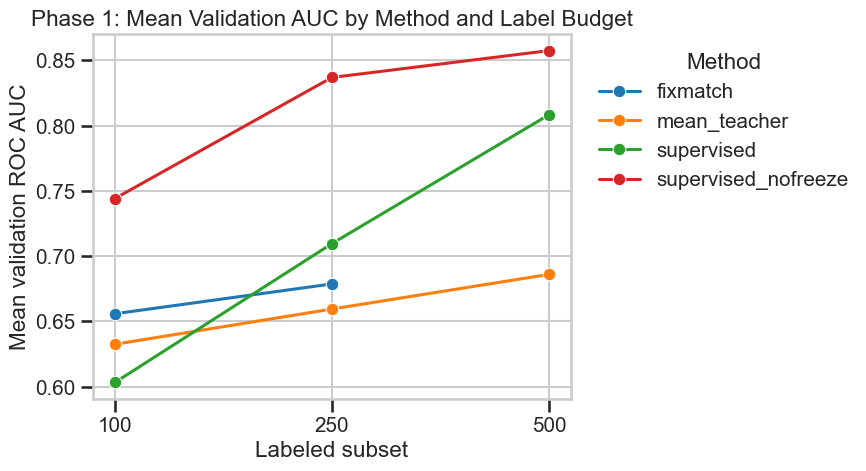

In [5]:
ssl_runs = load_ssl_closure()
ssl_grouped = (
    ssl_runs.groupby(["method", "subset"], as_index=False)
    .agg(
        mean_val_auc=("val_auc", "mean"),
        mean_test_auc=("test_auc", "mean"),
        mean_sens=("sensitivity", "mean"),
        mean_spec=("specificity", "mean"),
    )
)

pivot_val = ssl_grouped.pivot(index="subset", columns="method", values="mean_val_auc").sort_index()
display(pivot_val.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = ssl_grouped.copy()
plot_df["subset"] = plot_df["subset"].astype(str)
sns.lineplot(
    data=plot_df,
    x="subset",
    y="mean_val_auc",
    hue="method",
    marker="o",
    linewidth=2.2,
    ax=ax,
)
ax.set_title("Phase 1: Mean Validation AUC by Method and Label Budget")
ax.set_xlabel("Labeled subset")
ax.set_ylabel("Mean validation ROC AUC")
ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Phase 1 conclusion**

- The frozen supervised baseline was misleadingly weak.
- The corrected no-freeze supervised baseline clearly beat vanilla FixMatch and Mean Teacher.
- That closed the vanilla SSL chapter and shifted the project into supervised-first development.


## Phase 2: Supervised Sweep Results

Once the project pivoted, the next question became: which supervised direction actually improves the
corrected baseline? The broad sweep showed that bigger was not better here. The winning regime stayed at
512px with EfficientNet-B0, and the strongest branch came from regularization, not from scaling up image
size or backbone depth.


,config_name,family,mean_val_auc,mean_test_auc
3,default_nofreeze_ls,regularization,0.8797,0.7462
5,default_nofreeze_res512,baseline,0.8575,0.7518
0,default_nofreeze_aug_safe,regularization,0.8390,0.7555
1,default_nofreeze_b2,backbone,0.8134,0.7183
2,default_nofreeze_b3,backbone,0.7847,0.6577
6,default_nofreeze_res768,resolution,0.7463,0.6798
4,default_nofreeze_res1024,resolution,0.6887,0.6070


,config_name,mean_val_auc,mean_test_auc,mean_sensitivity,mean_specificity
0,default_nofreeze_res512,0.8575,0.7518,0.7156,0.6468
1,default_nofreeze_aug_safe,0.8390,0.7555,0.6480,0.7095
2,default_nofreeze_ls,0.8797,0.7462,0.6550,0.6850
3,default_nofreeze_aug_safe_ls,0.8503,0.7284,0.6434,0.6835


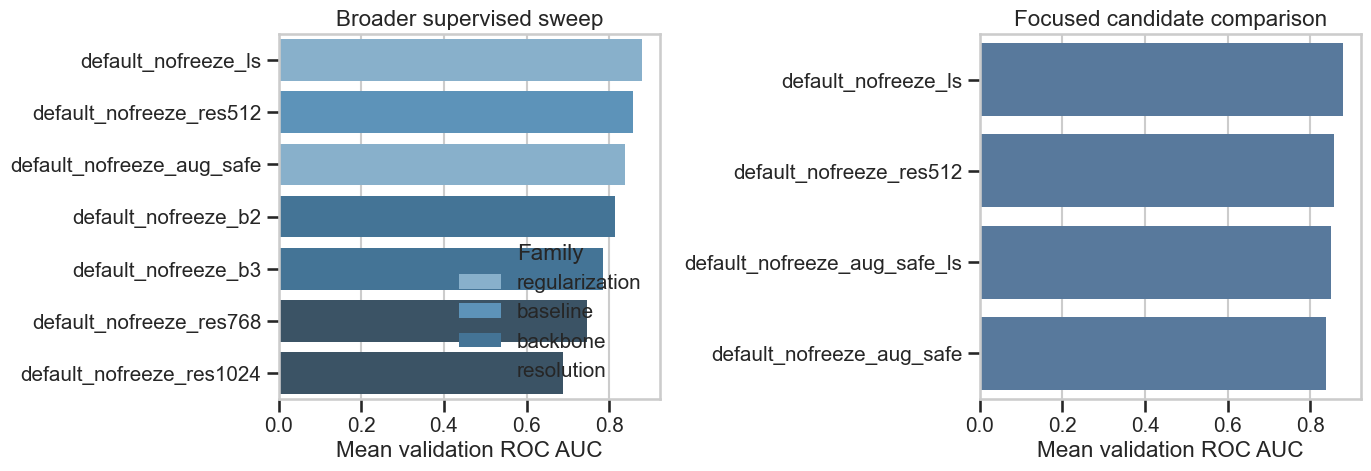

In [6]:
sweep_grouped = load_supervised_sweep_summary()
candidate_grouped = load_candidate_summary()

key_sweep = sweep_grouped[
    sweep_grouped["config_name"].isin(
        [
            "default_nofreeze_res512",
            "default_nofreeze_res768",
            "default_nofreeze_res1024",
            "default_nofreeze_b2",
            "default_nofreeze_b3",
            "default_nofreeze_aug_safe",
            "default_nofreeze_ls",
            "default_nofreeze_aug_safe_ls",
        ]
    )
].copy()
key_sweep = key_sweep.sort_values("mean_val_auc", ascending=False)

display(key_sweep[["config_name", "family", "mean_val_auc", "mean_test_auc"]].round(4))
display(candidate_grouped[["config_name", "mean_val_auc", "mean_test_auc", "mean_sensitivity", "mean_specificity"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=key_sweep,
    x="mean_val_auc",
    y="config_name",
    hue="family",
    dodge=False,
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title("Broader supervised sweep")
axes[0].set_xlabel("Mean validation ROC AUC")
axes[0].set_ylabel("")
axes[0].legend(title="Family", loc="lower right")

candidate_plot = candidate_grouped.sort_values("mean_val_auc", ascending=False).copy()
sns.barplot(
    data=candidate_plot,
    x="mean_val_auc",
    y="config_name",
    ax=axes[1],
    color="#4C78A8",
)
axes[1].set_title("Focused candidate comparison")
axes[1].set_xlabel("Mean validation ROC AUC")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Phase 2 conclusion**

- Higher resolutions and deeper EfficientNet variants did not beat the simpler 512px EfficientNet-B0 setup.
- `aug_safe` improved the specificity side of the tradeoff.
- `label_smoothing` produced the strongest ranking candidate and became the family worth promoting into a final optimizer decision.


## Phase 3: Final Adam vs AdamW Decision

The final phase was deliberately narrow. Instead of continuing broad sweeps, the project took the winning
`label_smoothing` family and forced a focused head-to-head between Adam and AdamW, then checked that result
against the earlier optimizer-recovery evidence.


**Fresh 45/46/47 view**

,config_name,mean_val_auc,mean_test_auc,mean_test_pr_auc,mean_test_brier_score,mean_test_ece,mean_test_sensitivity,mean_test_specificity,mean_spec_at_sens_090,mean_exam_auc
1,default_nofreeze_ls_adamw,0.8568,0.7602,0.6889,0.2161,0.1572,0.7506,0.6208,0.5979,0.7708
0,default_nofreeze_ls_adam,0.8040,0.7189,0.6168,0.2169,0.1014,0.6014,0.7064,0.4021,0.7227


**Combined 6-seed view (42-47)**

,config_name,runs,mean_val_auc,mean_test_auc,mean_test_pr_auc,mean_test_brier_score,mean_test_ece,mean_test_sensitivity,mean_test_specificity,mean_spec_at_sens_090,mean_exam_auc
1,default_nofreeze_ls_adamw,6,0.8633,0.7589,0.6748,0.2188,0.1513,0.7110,0.6651,0.5833,0.7668
0,default_nofreeze_ls_adam,6,0.8418,0.7326,0.6437,0.2146,0.1084,0.6282,0.6957,0.4709,0.7424
2,default_nofreeze_ls_sgd,3,0.8324,0.7590,0.6814,0.2098,0.1132,0.7529,0.6361,0.5107,0.7726


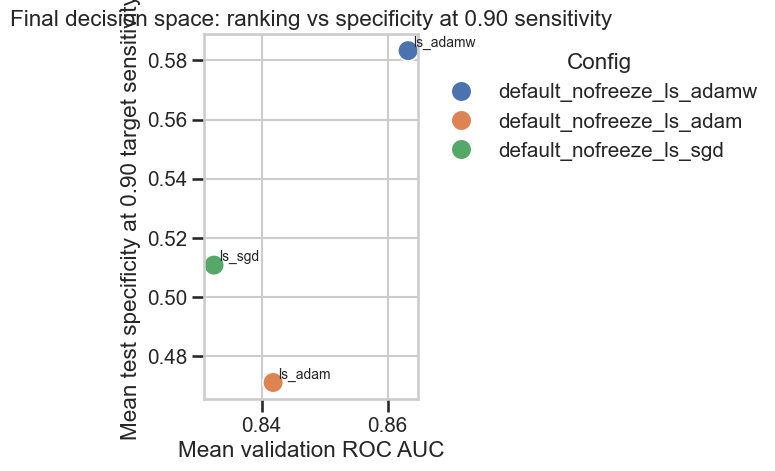

In [7]:
fresh_h2h = load_fresh_head_to_head().sort_values("mean_val_auc", ascending=False)
combined_h2h = load_combined_head_to_head().sort_values("mean_val_auc", ascending=False)

display(Markdown("**Fresh 45/46/47 view**"))
display(
    fresh_h2h[
        [
            "config_name",
            "mean_val_auc",
            "mean_test_auc",
            "mean_test_pr_auc",
            "mean_test_brier_score",
            "mean_test_ece",
            "mean_test_sensitivity",
            "mean_test_specificity",
            "mean_spec_at_sens_090",
            "mean_exam_auc",
        ]
    ].round(4)
)

display(Markdown("**Combined 6-seed view (42-47)**"))
display(
    combined_h2h[
        [
            "config_name",
            "runs",
            "mean_val_auc",
            "mean_test_auc",
            "mean_test_pr_auc",
            "mean_test_brier_score",
            "mean_test_ece",
            "mean_test_sensitivity",
            "mean_test_specificity",
            "mean_spec_at_sens_090",
            "mean_exam_auc",
        ]
    ].round(4)
)

fig, ax = plt.subplots(figsize=(7, 5))
plot_df = combined_h2h.copy()
plot_df["label"] = plot_df["config_name"].str.replace("default_nofreeze_", "", regex=False)
sns.scatterplot(
    data=plot_df,
    x="mean_val_auc",
    y="mean_spec_at_sens_090",
    hue="config_name",
    s=220,
    ax=ax,
    palette="deep",
)
for _, row in plot_df.iterrows():
    ax.text(row["mean_val_auc"] + 0.0008, row["mean_spec_at_sens_090"] + 0.0015, row["label"], fontsize=10)
ax.set_title("Final decision space: ranking vs specificity at 0.90 sensitivity")
ax.set_xlabel("Mean validation ROC AUC")
ax.set_ylabel("Mean test specificity at 0.90 target sensitivity")
ax.legend(title="Config", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Phase 3 conclusion**

- `default_nofreeze_ls_adamw` won the fresh-seed round and the combined 6-seed view.
- `default_nofreeze_ls_adam` stayed slightly better calibrated, but it lost too much on validation AUC,
  test AUC, sensitivity, and fixed-sensitivity specificity.
- That made `label_smoothing + adamw` the promoted baseline.


## Current Best Model

The project now has a clear recommended baseline. It is still a research model, not a deployment-ready
clinical system, but it is the strongest decision-support candidate produced so far and a much better
foundation than the earlier SSL branches.


In [8]:
promoted = combined_h2h.loc[combined_h2h["config_name"] == "default_nofreeze_ls_adamw"].iloc[0]
comparison = combined_h2h.loc[combined_h2h["config_name"] == "default_nofreeze_ls_adam"].iloc[0]

promoted_summary = pd.DataFrame(
    [
        {"field": "Promoted baseline", "value": "default_nofreeze_ls_adamw"},
        {"field": "Backbone", "value": "EfficientNet-B0"},
        {"field": "Image size", "value": "512"},
        {"field": "Optimizer", "value": "AdamW"},
        {"field": "Label smoothing", "value": "0.1"},
        {"field": "Mean validation ROC AUC", "value": f"{promoted['mean_val_auc']:.4f}"},
        {"field": "Mean test ROC AUC", "value": f"{promoted['mean_test_auc']:.4f}"},
        {"field": "Mean test PR AUC", "value": f"{promoted['mean_test_pr_auc']:.4f}"},
        {"field": "Mean test sensitivity", "value": f"{promoted['mean_test_sensitivity']:.4f}"},
        {"field": "Mean test specificity", "value": f"{promoted['mean_test_specificity']:.4f}"},
        {"field": "Mean specificity at 0.90 sensitivity", "value": f"{promoted['mean_spec_at_sens_090']:.4f}"},
        {"field": "Mean exam ROC AUC", "value": f"{promoted['mean_exam_auc']:.4f}"},
    ]
)

delta_vs_adam = pd.DataFrame(
    [
        {"metric": "Validation ROC AUC", "adamw_minus_adam": promoted["mean_val_auc"] - comparison["mean_val_auc"]},
        {"metric": "Test ROC AUC", "adamw_minus_adam": promoted["mean_test_auc"] - comparison["mean_test_auc"]},
        {"metric": "Test PR AUC", "adamw_minus_adam": promoted["mean_test_pr_auc"] - comparison["mean_test_pr_auc"]},
        {"metric": "Test sensitivity", "adamw_minus_adam": promoted["mean_test_sensitivity"] - comparison["mean_test_sensitivity"]},
        {"metric": "Specificity at 0.90 sensitivity", "adamw_minus_adam": promoted["mean_spec_at_sens_090"] - comparison["mean_spec_at_sens_090"]},
        {"metric": "Test ECE", "adamw_minus_adam": promoted["mean_test_ece"] - comparison["mean_test_ece"]},
    ]
)

display(promoted_summary)
display(delta_vs_adam.round(4))


,field,value
0,Promoted baseline,default_nofreeze_ls_adamw
1,Backbone,EfficientNet-B0
2,Image size,512
3,Optimizer,AdamW
4,Label smoothing,0.1
5,Mean validation ROC AUC,0.8633
6,Mean test ROC AUC,0.7589
7,Mean test PR AUC,0.6748
8,Mean test sensitivity,0.7110
9,Mean test specificity,0.6651


,metric,adamw_minus_adam
0,Validation ROC AUC,0.0214
1,Test ROC AUC,0.0263
2,Test PR AUC,0.0310
3,Test sensitivity,0.0828
4,Specificity at 0.90 sensitivity,0.1124
5,Test ECE,0.0429


## Future Work and Clinical Path

The next bottleneck is no longer broad model search. It is model quality in a clinical sense: calibration,
failure understanding, grouped reasoning at the exam level, and external validation. That is what makes the
current baseline useful as a research foundation rather than just a better training run.

**Near-term priorities**

- Calibrate the promoted AdamW model, starting with temperature scaling
- Review false positives, false negatives, and subgroup behavior
- Move from single-image classification toward exam-level and multi-view modeling
- Validate on additional mammography datasets to probe source-shift robustness

**Clinical framing**

A realistic future deployment path would frame the model as radiologist decision support, not autonomous
diagnosis. That would require stronger calibration, external validation, subgroup robustness evidence,
reader-study style evaluation, and rigorous documentation and change control.

## Appendix and Deeper Dives

The supporting notebooks remain useful for topical deep dives:

- [`01_data_exploration.ipynb`](01_data_exploration.ipynb) for dataset context
- [`02_training_curves.ipynb`](02_training_curves.ipynb) for training history inspection
- [`03_embeddings.ipynb`](03_embeddings.ipynb) for feature-space exploration
- [`04_model_interpretation.ipynb`](04_model_interpretation.ipynb) for confidence, calibration, and Grad-CAM work
